# Notebook06: Final Results and Confusion Analysis


**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

This notebook displays the saved results used in the Results and Discussion chapters.

## Setup

Imports and file paths.

In [50]:

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [51]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from IPython.display import display

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


print(f"Python : {sys.version.split()[0]}")
print(f"pandas : {pd.__version__}")
print(f"numpy  : {np.__version__}")
print(f"PyTorch     : {torch.__version__}")


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Device      : {DEVICE}")
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print(f"Device      : {DEVICE}")

Python : 3.13.15
pandas : 2.2.3
numpy  : 2.1.3
PyTorch     : 2.11.0+cu130
Device      : cuda
GPU         : NVIDIA L4


## 1. Results files

Check the saved tables and predictions from Notebook 05.

In [52]:
from pathlib import Path


## Project paths

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation_Data")


## Notebook 05 final-evaluation outputs

BASE_DIR = PROJECT_ROOT / "FinalEvaluation_Folder"

TABLES_DIR = BASE_DIR / "tables"
PREDICTIONS_DIR = BASE_DIR / "predictions"


## Original model prediction outputs

BASELINE_PREDICTION_DIR = PROJECT_ROOT / "Baseline" / "predictions"
MTL_PREDICTION_DIR = PROJECT_ROOT / "MultiTask" / "predictions"


## Detailed post-hoc outputs

DETAILED_OUTPUTS_DIR = BASE_DIR / "Detailed_Outputs"

DETAILED_TABLE_DIR = DETAILED_OUTPUTS_DIR / "tables"
DETAILED_FIGURE_DIR = DETAILED_OUTPUTS_DIR / "figures"


for directory in [
    DETAILED_TABLE_DIR,
    DETAILED_FIGURE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 67)
print(f"{'Project paths':^67}")
print("=" * 67, "\n")

print(f"Final evaluation : {BASE_DIR}")
print(f"Tables           : {TABLES_DIR}")
print(f"Predictions      : {PREDICTIONS_DIR}")
print(f"Baseline         : {BASELINE_PREDICTION_DIR}")
print(f"Multi-task       : {MTL_PREDICTION_DIR}")
print(f"Detailed outputs : {DETAILED_OUTPUTS_DIR}")



                           Project paths                           

Final evaluation : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder
Tables           : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder/tables
Predictions      : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder/predictions
Baseline         : /content/drive/MyDrive/Dissertation_Data/Baseline/predictions
Multi-task       : /content/drive/MyDrive/Dissertation_Data/MultiTask/predictions
Detailed outputs : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder/Detailed_Outputs


In [53]:
## Detailed-analysis settings

FINAL_TRAIN_SEEDS = (41, 42, 43)
MODEL_NAMES = ("Baseline", "Full MTL")
TARGET_SENSITIVITIES = (0.90, 0.95)

OPERATING_POINTS = (
    "Argmax",
    "90% sensitivity",
    "95% sensitivity",
)

print("=" * 67)
print(f"{'Detailed-analysis settings':^67}")
print("=" * 67, "\n")

print(f"Seeds             : {FINAL_TRAIN_SEEDS}")
print(f"Models            : {MODEL_NAMES}")
print(f"Target sensitivity: {TARGET_SENSITIVITIES}")
print(f"Operating points  : {OPERATING_POINTS}")

                    Detailed-analysis settings                     

Seeds             : (41, 42, 43)
Models            : ('Baseline', 'Full MTL')
Target sensitivity: (0.9, 0.95)
Operating points  : ('Argmax', '90% sensitivity', '95% sensitivity')


## 2. Table for Section 4.1: Main ISIC comparison

Balanced accuracy and macro AUROC for the diagnosis-only baseline and full multi-task configuration across seeds 41, 42 and 43.


In [54]:
main_by_seed = pd.read_csv( TABLES_DIR / "main_comparison_by_seed.csv")

display(main_by_seed)

,Metric,Seed,Baseline,Full MTL,Difference
0,3-class balanced accuracy,41,0.702035,0.690308,-0.011726
1,3-class balanced accuracy,42,0.693775,0.721361,0.027587
2,3-class balanced accuracy,43,0.732326,0.686757,-0.045569
3,3-class macro AUROC,41,0.907645,0.901028,-0.006617
4,3-class macro AUROC,42,0.902110,0.907099,0.004990
5,3-class macro AUROC,43,0.891064,0.904674,0.013610
6,Malignant vs rest AUROC,41,0.881783,0.872378,-0.009405
7,Malignant vs rest AUROC,42,0.886004,0.877909,-0.008095
8,Malignant vs rest AUROC,43,0.845429,0.880352,0.034923
9,Melanoma vs rest AUROC,41,0.799351,0.774729,-0.024622


In [55]:
main_summary = pd.read_csv( TABLES_DIR / "main_comparison_summary.csv")

display(main_summary)


,Metric,Baseline mean,Baseline SD,Full MTL mean,Full MTL SD,Difference mean,Difference SD
0,3-class balanced accuracy,0.709378,0.020298,0.699476,0.019037,-0.009903,0.036612
1,3-class macro AUROC,0.900273,0.008442,0.904267,0.003056,0.003994,0.010150
2,Malignant vs rest AUROC,0.871072,0.022307,0.876880,0.004086,0.005808,0.025223
3,Melanoma vs rest AUROC,0.788565,0.013757,0.785810,0.017293,-0.002756,0.030954


## 3. Table for Section 4.2: Binary AUROC

Malignant-versus-rest and melanoma-versus-rest AUROC for the three main seeds.

In [56]:

binary_auc = main_by_seed[
    main_by_seed["Metric"].isin([
        "Malignant vs rest AUROC",
        "Melanoma vs rest AUROC"
    ])
]

display(binary_auc)



,Metric,Seed,Baseline,Full MTL,Difference
6,Malignant vs rest AUROC,41,0.881783,0.872378,-0.009405
7,Malignant vs rest AUROC,42,0.886004,0.877909,-0.008095
8,Malignant vs rest AUROC,43,0.845429,0.880352,0.034923
9,Melanoma vs rest AUROC,41,0.799351,0.774729,-0.024622
10,Melanoma vs rest AUROC,42,0.773073,0.805736,0.032663
11,Melanoma vs rest AUROC,43,0.793272,0.776964,-0.016309


In [57]:

binary_summary = main_summary[
    main_summary["Metric"].isin([
        "Malignant vs rest AUROC",
        "Melanoma vs rest AUROC"
    ])
]

display(binary_summary)

,Metric,Baseline mean,Baseline SD,Full MTL mean,Full MTL SD,Difference mean,Difference SD
2,Malignant vs rest AUROC,0.871072,0.022307,0.87688,0.004086,0.005808,0.025223
3,Melanoma vs rest AUROC,0.788565,0.013757,0.78581,0.017293,-0.002756,0.030954



## 4. Table for Section 4.2: Operating points

Test sensitivity and specificity after applying the validation-selected 90% and 95% sensitivity operating points.

In [58]:

operating_by_seed = pd.read_csv( TABLES_DIR / "main_operating_by_seed.csv")

display(operating_by_seed)



,Evaluation,Model,Seed,Target sensitivity,Test sensitivity,Test FPR
0,Malignant vs rest,Baseline,41,0.90,0.897494,0.374901
1,Malignant vs rest,Baseline,41,0.95,0.943052,0.472376
2,Malignant vs rest,Full MTL,41,0.90,0.902050,0.354775
3,Malignant vs rest,Full MTL,41,0.95,0.940015,0.461721
4,Malignant vs rest,Baseline,42,0.90,0.895216,0.325178
5,Malignant vs rest,Baseline,42,0.95,0.955961,0.481847
6,Malignant vs rest,Full MTL,42,0.90,0.899013,0.365825
7,Malignant vs rest,Full MTL,42,0.95,0.942293,0.451066
8,Malignant vs rest,Baseline,43,0.90,0.895976,0.441200
9,Malignant vs rest,Baseline,43,0.95,0.945330,0.544199


In [59]:


operating_summary = pd.read_csv( TABLES_DIR / "main_operating_summary.csv" )

display(operating_summary)

,Evaluation,Target sensitivity,Model,Test sensitivity mean,Test sensitivity SD,Test FPR mean,Test FPR SD
0,Malignant vs rest,0.90,Baseline,0.896229,0.001160,0.380426,0.058208
1,Malignant vs rest,0.90,Full MTL,0.896735,0.006749,0.346882,0.023888
2,Malignant vs rest,0.95,Baseline,0.948114,0.006890,0.499474,0.039021
3,Malignant vs rest,0.95,Full MTL,0.944065,0.005168,0.460931,0.009496
4,Melanoma vs rest,0.90,Baseline,0.914258,0.012459,0.513137,0.016813
5,Melanoma vs rest,0.90,Full MTL,0.882948,0.009025,0.513137,0.032792
6,Melanoma vs rest,0.95,Baseline,0.954239,0.009837,0.602300,0.032224
7,Melanoma vs rest,0.95,Full MTL,0.943642,0.008046,0.605888,0.021124


## 5. Table for Section 4.3: Calibration

ECE and multiclass Brier score for the diagnosis-only baseline and full multi-task configuration.

In [60]:
calibration_by_seed = pd.read_csv( TABLES_DIR / "isic_calibration_by_run.csv" )

display(calibration_by_seed)



,Model,Seed,Top-label ECE,Multiclass Brier
0,Baseline,41,0.078781,0.320289
1,Baseline,42,0.118326,0.330357
2,Baseline,43,0.065416,0.362707
3,Full MTL,41,0.009956,0.316327
4,Full MTL,42,0.034108,0.307543
5,Full MTL,43,0.038682,0.295385


In [61]:


calibration_summary = pd.read_csv( TABLES_DIR / "isic_calibration_summary.csv" )

display(calibration_summary)




,Model,ECE mean,ECE SD,Brier mean,Brier SD
0,Baseline,0.087508,0.027513,0.337784,0.022163
1,Full MTL,0.027582,0.015435,0.306418,0.010516


## 6. Table for Section 4.4: Auxiliary tasks

Balanced accuracy for the seven Derm7pt auxiliary heads in the full multi-task configuration.

In [62]:



aux_by_seed = pd.read_csv( TABLES_DIR / "derm7pt_auxiliary_by_seed.csv" )

display(aux_by_seed)



#

,Seed,Task,Balanced accuracy,N
0,41,pigment_network,0.634183,395
1,41,blue_whitish_veil,0.864583,395
2,41,vascular_structures,0.636306,395
3,41,pigmentation,0.629066,395
4,41,streaks,0.648346,395
5,41,dots_and_globules,0.553070,395
6,41,regression_structures,0.635846,395
7,42,pigment_network,0.665189,395
8,42,blue_whitish_veil,0.814271,395
9,42,vascular_structures,0.532547,395


In [63]:


aux_summary = pd.read_csv( TABLES_DIR / "derm7pt_auxiliary_summary.csv" )

display(aux_summary)



,Task,Balanced accuracy mean,Balanced accuracy SD,N
0,pigment_network,0.640081,0.022740,395
1,blue_whitish_veil,0.818993,0.043422,395
2,vascular_structures,0.580315,0.052366,395
3,pigmentation,0.591943,0.036399,395
4,streaks,0.627108,0.024487,395
5,dots_and_globules,0.559579,0.008055,395
6,regression_structures,0.688930,0.047639,395


## 7. Table for Section 4.4: Leave-one-out ablations

Seed-42 results for the full multi-task configuration and the seven leave-one-out ablations.

The ablations are single-seed exploratory results.


In [64]:

ablation_results = pd.read_csv( TABLES_DIR / "ablation_diagnostic_results.csv" )

display(ablation_results)




,Run,Removed task,3-class balanced accuracy,3-class macro AUROC,Malignant vs rest AUROC,Melanoma vs rest AUROC
0,Full MTL,NaN,0.721361,0.907099,0.877909,0.805736
1,Ablation,pigment_network,0.708607,0.902871,0.882988,0.788118
2,Ablation,blue_whitish_veil,0.681381,0.893208,0.869125,0.779718
3,Ablation,vascular_structures,0.710236,0.908570,0.884185,0.804132
4,Ablation,pigmentation,0.682636,0.900834,0.886375,0.764513
5,Ablation,streaks,0.707407,0.913102,0.888355,0.762292
6,Ablation,dots_and_globules,0.699809,0.904899,0.885518,0.773400
7,Ablation,regression_structures,0.704016,0.911650,0.891185,0.797300


In [65]:

ablation_difference = pd.read_csv( TABLES_DIR / "ablation_difference_from_full_mtl.csv" )

display(ablation_difference)


,Removed task,Difference: 3-class balanced accuracy,Difference: 3-class macro AUROC,Difference: Malignant vs rest AUROC,Difference: Melanoma vs rest AUROC
0,pigment_network,-0.012755,-0.004228,0.005079,-0.017618
1,blue_whitish_veil,-0.039981,-0.013891,-0.008784,-0.026018
2,vascular_structures,-0.011125,0.001470,0.006275,-0.001604
3,pigmentation,-0.038726,-0.006265,0.008466,-0.041223
4,streaks,-0.013954,0.006003,0.010446,-0.043444
5,dots_and_globules,-0.021552,-0.002200,0.007609,-0.032336
6,regression_structures,-0.017346,0.004551,0.013275,-0.008436


## 8. Table for Section 4.5: Derm7pt

Diagnostic results on the mapped Derm7pt test subset across seeds 41, 42 and 43.

This test subset was held out, but it was not fully independent for the full multi-task configuration because Derm7pt training images provided auxiliary supervision.

In [66]:
derm7pt_by_seed = pd.read_csv( TABLES_DIR / "derm7pt_diagnostic_by_seed.csv" )

display(derm7pt_by_seed)



,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.738005,0.821087,355
1,Baseline,42,0.697874,0.785499,355
2,Baseline,43,0.714393,0.786217,355
3,Full MTL,41,0.735976,0.820405,355
4,Full MTL,42,0.762264,0.833764,355
5,Full MTL,43,0.671587,0.789880,355


In [67]:
derm7pt_summary = pd.read_csv( TABLES_DIR / "derm7pt_diagnostic_summary.csv" )

display(derm7pt_summary)



,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.716758,0.020170,0.797601,0.020343,355
1,Full MTL,0.723276,0.046654,0.814683,0.022495,355


## 9. Table for Section 4.5: PH2

Diagnostic results on PH2 across seeds 41, 42 and 43.

PH2 was used for inference-only external evaluation.


In [68]:
ph2_by_seed = pd.read_csv( TABLES_DIR / "ph2_diagnostic_by_seed.csv" )

display(ph2_by_seed)



,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.840625,0.891250,200
1,Baseline,42,0.803125,0.884062,200
2,Baseline,43,0.687500,0.758438,200
3,Full MTL,41,0.690625,0.884062,200
4,Full MTL,42,0.821875,0.883750,200
5,Full MTL,43,0.646875,0.826719,200


In [69]:
ph2_summary = pd.read_csv( TABLES_DIR / "ph2_diagnostic_summary.csv" )

display(ph2_summary)



,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.777083,0.079815,0.844583,0.074691,200
1,Full MTL,0.719792,0.091073,0.864844,0.033018,200


## 10. Transported operating points

ISIC-selected operating points applied unchanged to Derm7pt and PH2.

In [70]:
derm7pt_operating = pd.read_csv( TABLES_DIR / "derm7pt_transported_operating_points.csv")

display(derm7pt_operating)




,Evaluation,Model,Seed,Target sensitivity,Threshold source,Threshold,Validation sensitivity,Validation specificity,External sensitivity,External specificity,External FPR,N
0,Derm7pt,Baseline,41,0.90,"ISIC validation, malignant vs rest",0.211575,0.900704,0.623171,0.794872,0.714286,0.285714,355
1,Derm7pt,Baseline,41,0.95,"ISIC validation, malignant vs rest",0.123313,0.950743,0.532622,0.871795,0.600840,0.399160,355
2,Derm7pt,Baseline,42,0.90,"ISIC validation, malignant vs rest",0.130242,0.901486,0.680506,0.666667,0.718487,0.281513,355
3,Derm7pt,Baseline,42,0.95,"ISIC validation, malignant vs rest",0.035044,0.950743,0.518782,0.846154,0.537815,0.462185,355
4,Derm7pt,Baseline,43,0.90,"ISIC validation, malignant vs rest",0.165345,0.900704,0.566627,0.794872,0.537815,0.462185,355
5,Derm7pt,Baseline,43,0.95,"ISIC validation, malignant vs rest",0.112952,0.951525,0.459866,0.837607,0.386555,0.613445,355
6,Derm7pt,Full MTL,41,0.90,"ISIC validation, malignant vs rest",0.279277,0.901486,0.647687,0.709402,0.718487,0.281513,355
7,Derm7pt,Full MTL,41,0.95,"ISIC validation, malignant vs rest",0.194538,0.950743,0.545275,0.777778,0.617647,0.382353,355
8,Derm7pt,Full MTL,42,0.90,"ISIC validation, malignant vs rest",0.256327,0.901486,0.656386,0.820513,0.693277,0.306723,355
9,Derm7pt,Full MTL,42,0.95,"ISIC validation, malignant vs rest",0.178861,0.950743,0.561091,0.871795,0.613445,0.386555,355


In [71]:
ph2_operating = pd.read_csv( TABLES_DIR / "ph2_transported_operating_points.csv" )

display(ph2_operating)




,Evaluation,Model,Seed,Target sensitivity,Threshold source,Threshold,Validation sensitivity,Validation specificity,External sensitivity,External specificity,External FPR,N
0,PH2,Baseline,41,0.90,"ISIC validation, melanoma vs rest",0.184711,0.900875,0.499680,0.800,0.81875,0.18125,200
1,PH2,Baseline,41,0.95,"ISIC validation, melanoma vs rest",0.116529,0.950437,0.431775,0.850,0.73750,0.26250,200
2,PH2,Baseline,42,0.90,"ISIC validation, melanoma vs rest",0.071071,0.900875,0.500961,0.825,0.81250,0.18750,200
3,PH2,Baseline,42,0.95,"ISIC validation, melanoma vs rest",0.027531,0.950437,0.404869,0.875,0.64375,0.35625,200
4,PH2,Baseline,43,0.90,"ISIC validation, melanoma vs rest",0.163745,0.900875,0.475016,0.625,0.71250,0.28750,200
5,PH2,Baseline,43,0.95,"ISIC validation, melanoma vs rest",0.106168,0.950437,0.365471,0.800,0.59375,0.40625,200
6,PH2,Full MTL,41,0.90,"ISIC validation, melanoma vs rest",0.215192,0.900875,0.467969,0.750,0.86250,0.13750,200
7,PH2,Full MTL,41,0.95,"ISIC validation, melanoma vs rest",0.147424,0.950437,0.385010,0.875,0.75000,0.25000,200
8,PH2,Full MTL,42,0.90,"ISIC validation, melanoma vs rest",0.255500,0.900875,0.549007,0.875,0.66875,0.33125,200
9,PH2,Full MTL,42,0.95,"ISIC validation, melanoma vs rest",0.153625,0.950437,0.430173,0.925,0.47500,0.52500,200


## 11. Prediction files

Saved per-image predictions used for the Derm7pt and PH2 evaluations.


### 11.1 Derm7pt predictions

Check the mapped diagnostic labels, model, seed and broad malignancy score for the Derm7pt test subset.

In [72]:

derm7pt_predictions = pd.read_csv( PREDICTIONS_DIR / "derm7pt_diagnostic_predictions.csv" )

print("Rows:", len(derm7pt_predictions))
print("Columns:", derm7pt_predictions.columns.tolist())

display(
    derm7pt_predictions
    .groupby(["Model", "Seed"])
    .size()
    .reset_index(name="Rows")
)



Rows: 2130
Columns: ['metadata_index', 'diagnosis_group', 'binary_label', 'Model', 'Seed', 'P_Malignant', 'Predicted malignant']


,Model,Seed,Rows
0,Baseline,41,355
1,Baseline,42,355
2,Baseline,43,355
3,Full MTL,41,355
4,Full MTL,42,355
5,Full MTL,43,355


In [73]:
display(derm7pt_predictions.head(10))

,metadata_index,diagnosis_group,binary_label,Model,Seed,P_Malignant,Predicted malignant
0,6,BCC,1,Baseline,41,0.848385,1
1,8,BCC,1,Baseline,41,0.291248,0
2,15,BCC,1,Baseline,41,0.502090,1
3,34,BCC,1,Baseline,41,0.997688,1
4,41,BCC,1,Baseline,41,0.169221,0
5,42,NEV,0,Baseline,41,0.002783,0
6,53,NEV,0,Baseline,41,0.172567,0
7,55,NEV,0,Baseline,41,0.044251,0
8,64,NEV,0,Baseline,41,0.040165,0
9,70,NEV,0,Baseline,41,0.086934,0


In [74]:
display(
    derm7pt_predictions[
        (derm7pt_predictions["Model"] == "Full MTL") &
        (derm7pt_predictions["Seed"] == 41)
    ].head(10)
)

,metadata_index,diagnosis_group,binary_label,Model,Seed,P_Malignant,Predicted malignant
1065,6,BCC,1,Full MTL,41,0.915690,1
1066,8,BCC,1,Full MTL,41,0.311534,0
1067,15,BCC,1,Full MTL,41,0.888959,1
1068,34,BCC,1,Full MTL,41,0.931838,1
1069,41,BCC,1,Full MTL,41,0.629728,1
1070,42,NEV,0,Full MTL,41,0.032267,0
1071,53,NEV,0,Full MTL,41,0.019118,0
1072,55,NEV,0,Full MTL,41,0.171847,0
1073,64,NEV,0,Full MTL,41,0.059715,0
1074,70,NEV,0,Full MTL,41,0.172665,0


### 11.2 PH2 predictions

Check the diagnostic labels, model, seed and broad malignancy score for PH2.

In [75]:

ph2_predictions = pd.read_csv( PREDICTIONS_DIR / "ph2_diagnostic_predictions.csv" )

print("Rows:", len(ph2_predictions))
print("Columns:", ph2_predictions.columns.tolist())

display(
    ph2_predictions
    .groupby(["Model", "Seed"])
    .size()
    .reset_index(name="Rows")
)


Rows: 1200
Columns: ['Name', 'Clinical Diagnosis', 'Diagnosis', 'binary_label', 'Model', 'Seed', 'P_Malignant', 'Predicted malignant']


,Model,Seed,Rows
0,Baseline,41,200
1,Baseline,42,200
2,Baseline,43,200
3,Full MTL,41,200
4,Full MTL,42,200
5,Full MTL,43,200


In [76]:
display(ph2_predictions.head(10))

,Name,Clinical Diagnosis,Diagnosis,binary_label,Model,Seed,P_Malignant,Predicted malignant
0,IMD003,0,Common nevus,0,Baseline,41,0.001192,0
1,IMD009,0,Common nevus,0,Baseline,41,0.000766,0
2,IMD016,0,Common nevus,0,Baseline,41,0.010384,0
3,IMD022,0,Common nevus,0,Baseline,41,0.014254,0
4,IMD024,0,Common nevus,0,Baseline,41,0.016289,0
5,IMD025,0,Common nevus,0,Baseline,41,0.031795,0
6,IMD035,0,Common nevus,0,Baseline,41,0.399024,0
7,IMD038,0,Common nevus,0,Baseline,41,0.133732,0
8,IMD042,0,Common nevus,0,Baseline,41,0.017703,0
9,IMD044,0,Common nevus,0,Baseline,41,0.219669,0


In [77]:
display(
    ph2_predictions[
        (ph2_predictions["Model"] == "Full MTL") &
        (ph2_predictions["Seed"] == 41)
    ].head(10)
)

,Name,Clinical Diagnosis,Diagnosis,binary_label,Model,Seed,P_Malignant,Predicted malignant
600,IMD003,0,Common nevus,0,Full MTL,41,0.024411,0
601,IMD009,0,Common nevus,0,Full MTL,41,0.017258,0
602,IMD016,0,Common nevus,0,Full MTL,41,0.017322,0
603,IMD022,0,Common nevus,0,Full MTL,41,0.050247,0
604,IMD024,0,Common nevus,0,Full MTL,41,0.036688,0
605,IMD025,0,Common nevus,0,Full MTL,41,0.053260,0
606,IMD035,0,Common nevus,0,Full MTL,41,0.225154,0
607,IMD038,0,Common nevus,0,Full MTL,41,0.052090,0
608,IMD042,0,Common nevus,0,Full MTL,41,0.030146,0
609,IMD044,0,Common nevus,0,Full MTL,41,0.236287,0


## 12. Results used in Section 5.1: Diagnostic performance

This brings together the main ISIC comparison and operating-point results referred to in Section 5.1.

In [78]:

print("Main ISIC comparison")
display(main_summary)

print("90% operating points by seed")
display(
    operating_by_seed[
        operating_by_seed["Target sensitivity"] == 0.90
    ]
)

print("Operating-point summary")
display(operating_summary)

print("Calibration summary")
display(calibration_summary)



Main ISIC comparison


,Metric,Baseline mean,Baseline SD,Full MTL mean,Full MTL SD,Difference mean,Difference SD
0,3-class balanced accuracy,0.709378,0.020298,0.699476,0.019037,-0.009903,0.036612
1,3-class macro AUROC,0.900273,0.008442,0.904267,0.003056,0.003994,0.010150
2,Malignant vs rest AUROC,0.871072,0.022307,0.876880,0.004086,0.005808,0.025223
3,Melanoma vs rest AUROC,0.788565,0.013757,0.785810,0.017293,-0.002756,0.030954


90% operating points by seed


,Evaluation,Model,Seed,Target sensitivity,Test sensitivity,Test FPR
0,Malignant vs rest,Baseline,41,0.9,0.897494,0.374901
2,Malignant vs rest,Full MTL,41,0.9,0.902050,0.354775
4,Malignant vs rest,Baseline,42,0.9,0.895216,0.325178
6,Malignant vs rest,Full MTL,42,0.9,0.899013,0.365825
8,Malignant vs rest,Baseline,43,0.9,0.895976,0.441200
10,Malignant vs rest,Full MTL,43,0.9,0.889142,0.320047
12,Melanoma vs rest,Baseline,41,0.9,0.911850,0.501741
14,Melanoma vs rest,Full MTL,41,0.9,0.880058,0.540361
16,Melanoma vs rest,Baseline,42,0.9,0.927746,0.505223
18,Melanoma vs rest,Full MTL,42,0.9,0.875723,0.476733


Operating-point summary


,Evaluation,Target sensitivity,Model,Test sensitivity mean,Test sensitivity SD,Test FPR mean,Test FPR SD
0,Malignant vs rest,0.90,Baseline,0.896229,0.001160,0.380426,0.058208
1,Malignant vs rest,0.90,Full MTL,0.896735,0.006749,0.346882,0.023888
2,Malignant vs rest,0.95,Baseline,0.948114,0.006890,0.499474,0.039021
3,Malignant vs rest,0.95,Full MTL,0.944065,0.005168,0.460931,0.009496
4,Melanoma vs rest,0.90,Baseline,0.914258,0.012459,0.513137,0.016813
5,Melanoma vs rest,0.90,Full MTL,0.882948,0.009025,0.513137,0.032792
6,Melanoma vs rest,0.95,Baseline,0.954239,0.009837,0.602300,0.032224
7,Melanoma vs rest,0.95,Full MTL,0.943642,0.008046,0.605888,0.021124


Calibration summary


,Model,ECE mean,ECE SD,Brier mean,Brier SD
0,Baseline,0.087508,0.027513,0.337784,0.022163
1,Full MTL,0.027582,0.015435,0.306418,0.010516


## 13. Results used in Section 5.2: Calibration, auxiliary tasks and ablations

This brings together the calibration results, auxiliary-head performance and exploratory leave-one-out results referred to in Section 5.2.

In [79]:
print("Calibration by seed")
display(calibration_by_seed)

print("Auxiliary tasks")
display(aux_summary)

print("Leave-one-out ablations")
display(ablation_results)


Calibration by seed


,Model,Seed,Top-label ECE,Multiclass Brier
0,Baseline,41,0.078781,0.320289
1,Baseline,42,0.118326,0.330357
2,Baseline,43,0.065416,0.362707
3,Full MTL,41,0.009956,0.316327
4,Full MTL,42,0.034108,0.307543
5,Full MTL,43,0.038682,0.295385


Auxiliary tasks


,Task,Balanced accuracy mean,Balanced accuracy SD,N
0,pigment_network,0.640081,0.022740,395
1,blue_whitish_veil,0.818993,0.043422,395
2,vascular_structures,0.580315,0.052366,395
3,pigmentation,0.591943,0.036399,395
4,streaks,0.627108,0.024487,395
5,dots_and_globules,0.559579,0.008055,395
6,regression_structures,0.688930,0.047639,395


Leave-one-out ablations


,Run,Removed task,3-class balanced accuracy,3-class macro AUROC,Malignant vs rest AUROC,Melanoma vs rest AUROC
0,Full MTL,NaN,0.721361,0.907099,0.877909,0.805736
1,Ablation,pigment_network,0.708607,0.902871,0.882988,0.788118
2,Ablation,blue_whitish_veil,0.681381,0.893208,0.869125,0.779718
3,Ablation,vascular_structures,0.710236,0.908570,0.884185,0.804132
4,Ablation,pigmentation,0.682636,0.900834,0.886375,0.764513
5,Ablation,streaks,0.707407,0.913102,0.888355,0.762292
6,Ablation,dots_and_globules,0.699809,0.904899,0.885518,0.773400
7,Ablation,regression_structures,0.704016,0.911650,0.891185,0.797300


In [80]:
print("Full MTL balanced accuracy by seed")

display(
    main_by_seed[
        main_by_seed["Metric"] == "3-class balanced accuracy"
    ]
)


Full MTL balanced accuracy by seed


,Metric,Seed,Baseline,Full MTL,Difference
0,3-class balanced accuracy,41,0.702035,0.690308,-0.011726
1,3-class balanced accuracy,42,0.693775,0.721361,0.027587
2,3-class balanced accuracy,43,0.732326,0.686757,-0.045569


## 14. Results used in Section 5.3: Evaluation beyond ISIC

This brings together the Derm7pt and PH2 results compared in Section 5.3.

In [81]:
print("Derm7pt summary")
display(derm7pt_summary)

print("PH2 summary")
display(ph2_summary)



Derm7pt summary


,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.716758,0.020170,0.797601,0.020343,355
1,Full MTL,0.723276,0.046654,0.814683,0.022495,355


PH2 summary


,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N
0,Baseline,0.777083,0.079815,0.844583,0.074691,200
1,Full MTL,0.719792,0.091073,0.864844,0.033018,200


In [82]:
print("Derm7pt by seed")
display(derm7pt_by_seed)

print("PH2 by seed")
display(ph2_by_seed)



Derm7pt by seed


,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.738005,0.821087,355
1,Baseline,42,0.697874,0.785499,355
2,Baseline,43,0.714393,0.786217,355
3,Full MTL,41,0.735976,0.820405,355
4,Full MTL,42,0.762264,0.833764,355
5,Full MTL,43,0.671587,0.789880,355


PH2 by seed


,Model,Seed,Balanced accuracy,AUROC,N
0,Baseline,41,0.840625,0.891250,200
1,Baseline,42,0.803125,0.884062,200
2,Baseline,43,0.687500,0.758438,200
3,Full MTL,41,0.690625,0.884062,200
4,Full MTL,42,0.821875,0.883750,200
5,Full MTL,43,0.646875,0.826719,200


In [83]:


derm7pt_cross = derm7pt_summary.copy()
derm7pt_cross["Dataset"] = "Derm7pt"

ph2_cross = ph2_summary.copy()
ph2_cross["Dataset"] = "PH2"

cross_dataset = pd.concat(
    [derm7pt_cross, ph2_cross],
    ignore_index=True
)

display(cross_dataset)



,Model,Balanced accuracy mean,Balanced accuracy SD,AUROC mean,AUROC SD,N,Dataset
0,Baseline,0.716758,0.020170,0.797601,0.020343,355,Derm7pt
1,Full MTL,0.723276,0.046654,0.814683,0.022495,355,Derm7pt
2,Baseline,0.777083,0.079815,0.844583,0.074691,200,PH2
3,Full MTL,0.719792,0.091073,0.864844,0.033018,200,PH2


## 15. Confusion analysis

This section examines confusion on the melanoma versus nevus boundary using saved predictions only. No model is loaded and no new inference is run.

The analysis focuses on per-class behaviour, false-positive errors and operating points at fixed sensitivity. The 90% sensitivity operating point is treated as primary and 95% as secondary.

PH2 provides the cleanest cross-dataset diagnostic test because its melanoma, atypical nevus and common nevus labels map directly to melanoma versus nevus. Derm7pt is analysed separately using the mapped diagnostic labels, while recognising that its test split is held out but is not fully independent for the full multi-task model.

For ISIC, melanoma versus rest is analysed using the broad Malignant probability as the score. Indeterminate cases remain in the negative class, and the score should therefore be interpreted as a broad malignancy score rather than a melanoma-specific probability.

All new tables and figures are saved under `Detailed_Outputs`, leaving the original Notebook 05 outputs unchanged.

### 15.1 PH2 melanoma versus naevi

PH2 provides the cleanest cross-dataset diagnostic test because its melanoma, atypical nevus and common nevus labels map directly to melanoma versus nevus.

Melanoma is treated as positive and both nevus groups as negative. The analysis uses the saved `P_Malignant` score and the ISIC validation-selected 90% and 95% sensitivity thresholds applied unchanged.

In [84]:
## Load PH2 predictions


PH2_PREDICTIONS_PATH = PREDICTIONS_DIR / "ph2_diagnostic_predictions.csv"

ph2_confusion = pd.read_csv(PH2_PREDICTIONS_PATH)


print("=" * 67)
print(f"{'PH2 confusion-analysis input':^67}")
print("=" * 67, "\n")

print(f"File : {PH2_PREDICTIONS_PATH.name}")
print(f"Rows : {len(ph2_confusion)}")
print()

display(
    ph2_confusion
    .groupby(["Model", "Seed", "Diagnosis"])
    .size()
    .reset_index(name="N")
)

                   PH2 confusion-analysis input                    

File : ph2_diagnostic_predictions.csv
Rows : 1200



,Model,Seed,Diagnosis,N
0,Baseline,41,Atypical nevus,80
1,Baseline,41,Common nevus,80
2,Baseline,41,Melanoma,40
3,Baseline,42,Atypical nevus,80
4,Baseline,42,Common nevus,80
5,Baseline,42,Melanoma,40
6,Baseline,43,Atypical nevus,80
7,Baseline,43,Common nevus,80
8,Baseline,43,Melanoma,40
9,Full MTL,41,Atypical nevus,80


### 15.2 PH2 operating points

The 90% sensitivity operating point is treated as primary and 95% as secondary. Thresholds selected on ISIC validation are applied unchanged to PH2; no threshold is fitted on PH2.

In [85]:

## Load PH2 transported operating points


PH2_OPERATING_PATH = TABLES_DIR / "ph2_transported_operating_points.csv"

ph2_operating_confusion = pd.read_csv(PH2_OPERATING_PATH)


print("=" * 67)
print(f"{'PH2 transported operating points':^67}")
print("=" * 67, "\n")

display(
    ph2_operating_confusion[
        [
            "Model",
            "Seed",
            "Target sensitivity",
            "Threshold",
            "External sensitivity",
            "External specificity",
            "External FPR",
        ]
    ].round(4)
)

                 PH2 transported operating points                  



,Model,Seed,Target sensitivity,Threshold,External sensitivity,External specificity,External FPR
0,Baseline,41,0.90,0.1847,0.800,0.8188,0.1812
1,Baseline,41,0.95,0.1165,0.850,0.7375,0.2625
2,Baseline,42,0.90,0.0711,0.825,0.8125,0.1875
3,Baseline,42,0.95,0.0275,0.875,0.6438,0.3562
4,Baseline,43,0.90,0.1637,0.625,0.7125,0.2875
5,Baseline,43,0.95,0.1062,0.800,0.5938,0.4062
6,Full MTL,41,0.90,0.2152,0.750,0.8625,0.1375
7,Full MTL,41,0.95,0.1474,0.875,0.7500,0.2500
8,Full MTL,42,0.90,0.2555,0.875,0.6688,0.3312
9,Full MTL,42,0.95,0.1536,0.925,0.4750,0.5250


### 15.3 PH2 confusion and operating-point counts

Argmax counts describe the melanoma-versus-nevus confusion pattern. Additional counts are reported after applying the ISIC validation thresholds selected for 90% and 95% sensitivity. These thresholds are transported unchanged to PH2.


In [86]:
## PH2 confusion and operating-point counts


ph2_confusion_rows = []


for model in MODEL_NAMES:
    for seed in FINAL_TRAIN_SEEDS:

        subset = ph2_confusion[
            (ph2_confusion["Model"] == model)
            & (ph2_confusion["Seed"] == seed)
        ].copy()

        y_true = subset["binary_label"].astype(int)


        decisions = {
            "Argmax": subset["Predicted malignant"].astype(int),
        }


        for target in TARGET_SENSITIVITIES:

            threshold = ph2_operating_confusion.loc[
                (ph2_operating_confusion["Model"] == model)
                & (ph2_operating_confusion["Seed"] == seed)
                & np.isclose(
                    ph2_operating_confusion["Target sensitivity"],
                    target
                ),
                "Threshold",
            ].iloc[0]

            decisions[
                f"ISIC {int(target * 100)}% sensitivity threshold"
            ] = (
                subset["P_Malignant"] >= threshold
            ).astype(int)


        for operating_point, y_pred in decisions.items():

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            sensitivity = tp / (tp + fn)
            specificity = tn / (tn + fp)
            fpr = fp / (fp + tn)

            ph2_confusion_rows.append(
                {
                    "Model": model,
                    "Seed": seed,
                    "Decision rule": operating_point,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "TP": tp,
                    "Sensitivity": sensitivity,
                    "Specificity": specificity,
                    "FPR": fpr,
                }
            )


ph2_confusion_by_seed = pd.DataFrame(ph2_confusion_rows)

ph2_confusion_by_seed.to_csv(
    DETAILED_TABLE_DIR / "ph2_confusion_by_seed.csv",
    index=False
)


display(
    ph2_confusion_by_seed.round(4)
)

,Model,Seed,Decision rule,TN,FP,FN,TP,Sensitivity,Specificity,FPR
0,Baseline,41,Argmax,153,7,11,29,0.725,0.9562,0.0438
1,Baseline,41,ISIC 90% sensitivity threshold,131,29,8,32,0.800,0.8188,0.1812
2,Baseline,41,ISIC 95% sensitivity threshold,118,42,6,34,0.850,0.7375,0.2625
3,Baseline,42,Argmax,157,3,15,25,0.625,0.9812,0.0188
4,Baseline,42,ISIC 90% sensitivity threshold,130,30,7,33,0.825,0.8125,0.1875
5,Baseline,42,ISIC 95% sensitivity threshold,103,57,5,35,0.875,0.6438,0.3562
6,Baseline,43,Argmax,156,4,24,16,0.400,0.9750,0.0250
7,Baseline,43,ISIC 90% sensitivity threshold,114,46,15,25,0.625,0.7125,0.2875
8,Baseline,43,ISIC 95% sensitivity threshold,95,65,8,32,0.800,0.5938,0.4062
9,Full MTL,41,Argmax,157,3,24,16,0.400,0.9812,0.0188


### 15.3 PH2 confusion and operating-point counts

Argmax counts describe the melanoma-versus-nevus confusion pattern. Additional counts are reported after applying the ISIC validation thresholds selected for 90% and 95% sensitivity. These thresholds are transported unchanged to PH2.




In [87]:
## PH2 confusion and operating-point counts


ph2_confusion_rows = []


for model in MODEL_NAMES:
    for seed in FINAL_TRAIN_SEEDS:

        subset = ph2_confusion[
            (ph2_confusion["Model"] == model)
            & (ph2_confusion["Seed"] == seed)
        ].copy()

        y_true = subset["binary_label"].astype(int)


        decisions = {
            "Argmax": subset["Predicted malignant"].astype(int),
        }


        for target in TARGET_SENSITIVITIES:

            threshold = ph2_operating_confusion.loc[
                (ph2_operating_confusion["Model"] == model)
                & (ph2_operating_confusion["Seed"] == seed)
                & np.isclose(
                    ph2_operating_confusion["Target sensitivity"],
                    target
                ),
                "Threshold",
            ].iloc[0]

            decisions[
                f"ISIC {int(target * 100)}% sensitivity threshold"
            ] = (
                subset["P_Malignant"] >= threshold
            ).astype(int)


        for decision_rule, y_pred in decisions.items():

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            ph2_confusion_rows.append(
                {
                    "Model": model,
                    "Seed": seed,
                    "Decision rule": decision_rule,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "TP": tp,
                    "Sensitivity": tp / (tp + fn),
                    "Specificity": tn / (tn + fp),
                    "FPR": fp / (fp + tn),
                }
            )


ph2_confusion_by_seed = pd.DataFrame(ph2_confusion_rows)


display(
    ph2_confusion_by_seed.round(4)
)

,Model,Seed,Decision rule,TN,FP,FN,TP,Sensitivity,Specificity,FPR
0,Baseline,41,Argmax,153,7,11,29,0.725,0.9562,0.0438
1,Baseline,41,ISIC 90% sensitivity threshold,131,29,8,32,0.800,0.8188,0.1812
2,Baseline,41,ISIC 95% sensitivity threshold,118,42,6,34,0.850,0.7375,0.2625
3,Baseline,42,Argmax,157,3,15,25,0.625,0.9812,0.0188
4,Baseline,42,ISIC 90% sensitivity threshold,130,30,7,33,0.825,0.8125,0.1875
5,Baseline,42,ISIC 95% sensitivity threshold,103,57,5,35,0.875,0.6438,0.3562
6,Baseline,43,Argmax,156,4,24,16,0.400,0.9750,0.0250
7,Baseline,43,ISIC 90% sensitivity threshold,114,46,15,25,0.625,0.7125,0.2875
8,Baseline,43,ISIC 95% sensitivity threshold,95,65,8,32,0.800,0.5938,0.4062
9,Full MTL,41,Argmax,157,3,24,16,0.400,0.9812,0.0188


### 15.4 PH2 confusion matrices

Normalised confusion matrices show the melanoma-versus-nevus confusion pattern under the model's original argmax decision.



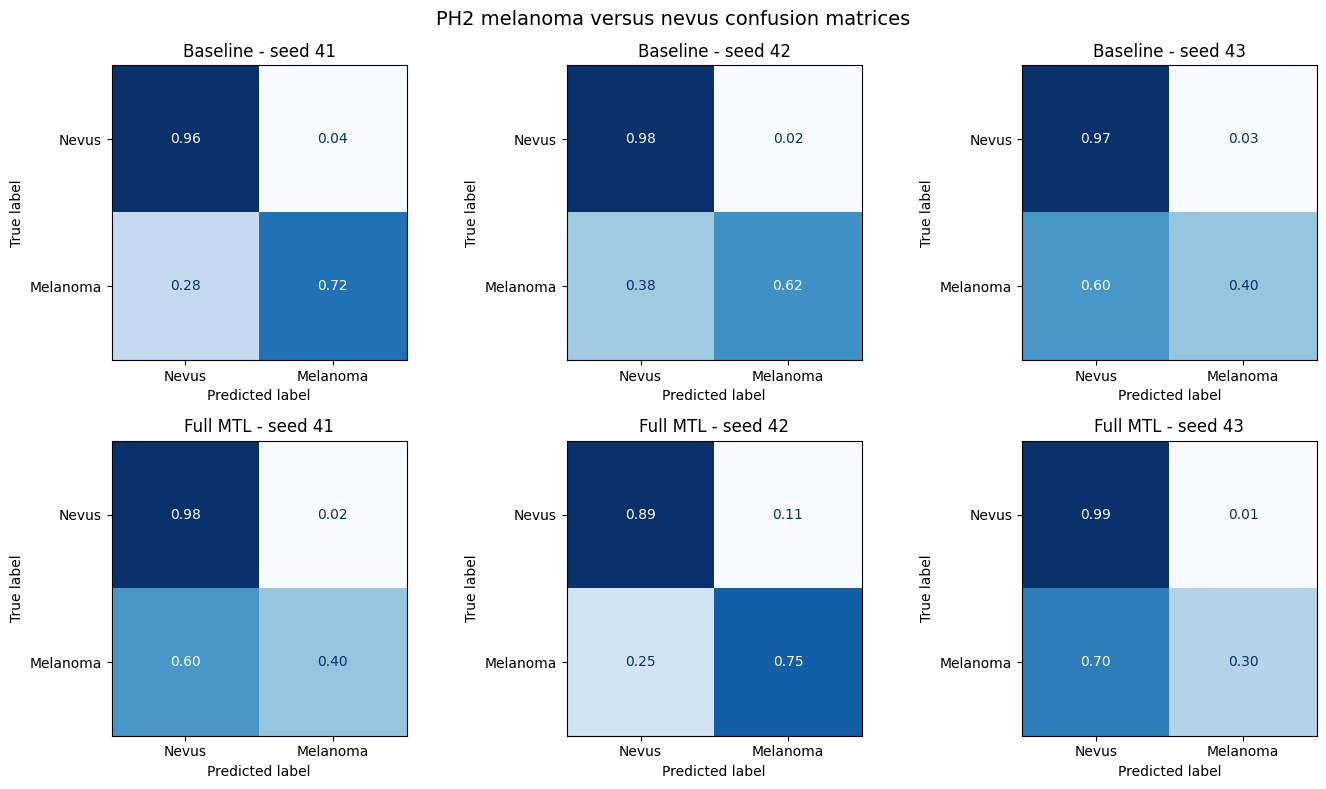

In [88]:

## Plot normalised PH2 confusion matrices


fig, axes = plt.subplots(2, 3, figsize=(14, 8))


for row_index, model in enumerate(MODEL_NAMES):

    for column_index, seed in enumerate(FINAL_TRAIN_SEEDS):

        dataframe = ph2_confusion[
            (ph2_confusion["Model"] == model)
            & (ph2_confusion["Seed"] == seed)
        ]

        confusion = confusion_matrix(
            dataframe["binary_label"].astype(int),
            dataframe["Predicted malignant"].astype(int),
            labels=[0, 1],
            normalize="true",
        )

        display_matrix = ConfusionMatrixDisplay(
            confusion_matrix=confusion,
            display_labels=["Nevus", "Melanoma"],
        )

        display_matrix.plot(
            ax=axes[row_index, column_index],
            cmap="Blues",
            colorbar=False,
            values_format=".2f",
        )

        axes[row_index, column_index].set_title(
            f"{model} - seed {seed}"
        )


fig.suptitle(
    "PH2 melanoma versus nevus confusion matrices",
    fontsize=14
)

plt.tight_layout()

PH2_CONFUSION_FIGURE_PATH = (
    DETAILED_FIGURE_DIR / "ph2_confusion_argmax.png"
)

plt.savefig(
    PH2_CONFUSION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 15.5 Derm7pt mapped diagnostic confusion analysis

Derm7pt is analysed using the existing diagnostic mapping: NEV and SK are treated as Benign, while MEL and BCC are treated as Malignant; MISC cases are excluded.

The test split is held out, but it is not fully independent for the full multi-task model because Derm7pt training images provided auxiliary supervision. The same broad `P_Malignant` score and transported ISIC validation thresholds are used.


In [89]:


## Load Derm7pt predictions


DERM7PT_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / "derm7pt_diagnostic_predictions.csv"
)

derm7pt_confusion = pd.read_csv(DERM7PT_PREDICTIONS_PATH)


print("=" * 67)
print(f"{'Derm7pt confusion-analysis input':^67}")
print("=" * 67, "\n")

print(f"File : {DERM7PT_PREDICTIONS_PATH.name}")
print(f"Rows : {len(derm7pt_confusion)}")
print()

display(
    derm7pt_confusion
    .groupby(["Model", "Seed", "diagnosis_group"])
    .size()
    .reset_index(name="N")
)


                 Derm7pt confusion-analysis input                  

File : derm7pt_diagnostic_predictions.csv
Rows : 2130



,Model,Seed,diagnosis_group,N
0,Baseline,41,BCC,16
1,Baseline,41,MEL,101
2,Baseline,41,NEV,219
3,Baseline,41,SK,19
4,Baseline,42,BCC,16
5,Baseline,42,MEL,101
6,Baseline,42,NEV,219
7,Baseline,42,SK,19
8,Baseline,43,BCC,16
9,Baseline,43,MEL,101


### 15.6 Derm7pt operating points

The 90% sensitivity operating point is treated as primary and 95% as secondary. Thresholds selected on ISIC validation are applied unchanged to the mapped Derm7pt test subset.



In [90]:
## Load Derm7pt transported operating points


DERM7PT_OPERATING_PATH = (
    TABLES_DIR / "derm7pt_transported_operating_points.csv"
)

derm7pt_operating_confusion = pd.read_csv(
    DERM7PT_OPERATING_PATH
)


print("=" * 67)
print(f"{'Derm7pt transported operating points':^67}")
print("=" * 67, "\n")

display(
    derm7pt_operating_confusion[
        [
            "Model",
            "Seed",
            "Target sensitivity",
            "Threshold",
            "External sensitivity",
            "External specificity",
            "External FPR",
        ]
    ].round(4)
)

               Derm7pt transported operating points                



,Model,Seed,Target sensitivity,Threshold,External sensitivity,External specificity,External FPR
0,Baseline,41,0.90,0.2116,0.7949,0.7143,0.2857
1,Baseline,41,0.95,0.1233,0.8718,0.6008,0.3992
2,Baseline,42,0.90,0.1302,0.6667,0.7185,0.2815
3,Baseline,42,0.95,0.0350,0.8462,0.5378,0.4622
4,Baseline,43,0.90,0.1653,0.7949,0.5378,0.4622
5,Baseline,43,0.95,0.1130,0.8376,0.3866,0.6134
6,Full MTL,41,0.90,0.2793,0.7094,0.7185,0.2815
7,Full MTL,41,0.95,0.1945,0.7778,0.6176,0.3824
8,Full MTL,42,0.90,0.2563,0.8205,0.6933,0.3067
9,Full MTL,42,0.95,0.1789,0.8718,0.6134,0.3866


### 15.8 Derm7pt confusion and operating-point counts

Argmax counts describe confusion between the mapped Benign and Malignant classes. Additional counts are reported after applying the ISIC validation thresholds selected for 90% and 95% sensitivity. These thresholds are applied unchanged to Derm7pt.



In [91]:

## Derm7pt confusion and operating-point counts


derm7pt_confusion_rows = []


for model in MODEL_NAMES:
    for seed in FINAL_TRAIN_SEEDS:

        subset = derm7pt_confusion[
            (derm7pt_confusion["Model"] == model)
            & (derm7pt_confusion["Seed"] == seed)
        ].copy()

        y_true = subset["binary_label"].astype(int)

        decisions = {
            "Argmax": subset["Predicted malignant"].astype(int),
        }


        for target in TARGET_SENSITIVITIES:

            threshold = derm7pt_operating_confusion.loc[
                (derm7pt_operating_confusion["Model"] == model)
                & (derm7pt_operating_confusion["Seed"] == seed)
                & np.isclose(
                    derm7pt_operating_confusion["Target sensitivity"],
                    target
                ),
                "Threshold",
            ].iloc[0]

            decisions[
                f"ISIC {int(target * 100)}% sensitivity threshold"
            ] = (
                subset["P_Malignant"] >= threshold
            ).astype(int)


        for decision_rule, y_pred in decisions.items():

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            derm7pt_confusion_rows.append(
                {
                    "Model": model,
                    "Seed": seed,
                    "Decision rule": decision_rule,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "TP": tp,
                    "Sensitivity": tp / (tp + fn),
                    "Specificity": tn / (tn + fp),
                    "FPR": fp / (fp + tn),
                }
            )


derm7pt_confusion_by_seed = pd.DataFrame(
    derm7pt_confusion_rows
)


display(
    derm7pt_confusion_by_seed.round(4)
)

,Model,Seed,Decision rule,TN,FP,FN,TP,Sensitivity,Specificity,FPR
0,Baseline,41,Argmax,215,23,50,67,0.5726,0.9034,0.0966
1,Baseline,41,ISIC 90% sensitivity threshold,170,68,24,93,0.7949,0.7143,0.2857
2,Baseline,41,ISIC 95% sensitivity threshold,143,95,15,102,0.8718,0.6008,0.3992
3,Baseline,42,Argmax,202,36,53,64,0.5470,0.8487,0.1513
4,Baseline,42,ISIC 90% sensitivity threshold,171,67,39,78,0.6667,0.7185,0.2815
5,Baseline,42,ISIC 95% sensitivity threshold,128,110,18,99,0.8462,0.5378,0.4622
6,Baseline,43,Argmax,218,20,57,60,0.5128,0.9160,0.0840
7,Baseline,43,ISIC 90% sensitivity threshold,128,110,24,93,0.7949,0.5378,0.4622
8,Baseline,43,ISIC 95% sensitivity threshold,92,146,19,98,0.8376,0.3866,0.6134
9,Full MTL,41,Argmax,212,26,49,68,0.5812,0.8908,0.1092


### 15.8 Derm7pt confusion and operating-point counts

Argmax counts describe confusion between the mapped Benign and Malignant classes. Additional counts are reported after applying the ISIC validation thresholds selected for 90% and 95% sensitivity. These thresholds are applied unchanged to Derm7pt.



In [92]:

## Derm7pt confusion and operating-point counts


derm7pt_confusion_rows = []


for model in MODEL_NAMES:
    for seed in FINAL_TRAIN_SEEDS:

        subset = derm7pt_confusion[
            (derm7pt_confusion["Model"] == model)
            & (derm7pt_confusion["Seed"] == seed)
        ].copy()

        y_true = subset["binary_label"].astype(int)

        decisions = {
            "Argmax": subset["Predicted malignant"].astype(int),
        }


        for target in TARGET_SENSITIVITIES:

            threshold = derm7pt_operating_confusion.loc[
                (derm7pt_operating_confusion["Model"] == model)
                & (derm7pt_operating_confusion["Seed"] == seed)
                & np.isclose(
                    derm7pt_operating_confusion["Target sensitivity"],
                    target
                ),
                "Threshold",
            ].iloc[0]

            decisions[
                f"ISIC {int(target * 100)}% sensitivity threshold"
            ] = (
                subset["P_Malignant"] >= threshold
            ).astype(int)


        for decision_rule, y_pred in decisions.items():

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            derm7pt_confusion_rows.append(
                {
                    "Model": model,
                    "Seed": seed,
                    "Decision rule": decision_rule,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "TP": tp,
                    "Sensitivity": tp / (tp + fn),
                    "Specificity": tn / (tn + fp),
                    "FPR": fp / (fp + tn),
                }
            )


derm7pt_confusion_by_seed = pd.DataFrame(
    derm7pt_confusion_rows
)


display(
    derm7pt_confusion_by_seed.round(4)
)








,Model,Seed,Decision rule,TN,FP,FN,TP,Sensitivity,Specificity,FPR
0,Baseline,41,Argmax,215,23,50,67,0.5726,0.9034,0.0966
1,Baseline,41,ISIC 90% sensitivity threshold,170,68,24,93,0.7949,0.7143,0.2857
2,Baseline,41,ISIC 95% sensitivity threshold,143,95,15,102,0.8718,0.6008,0.3992
3,Baseline,42,Argmax,202,36,53,64,0.5470,0.8487,0.1513
4,Baseline,42,ISIC 90% sensitivity threshold,171,67,39,78,0.6667,0.7185,0.2815
5,Baseline,42,ISIC 95% sensitivity threshold,128,110,18,99,0.8462,0.5378,0.4622
6,Baseline,43,Argmax,218,20,57,60,0.5128,0.9160,0.0840
7,Baseline,43,ISIC 90% sensitivity threshold,128,110,24,93,0.7949,0.5378,0.4622
8,Baseline,43,ISIC 95% sensitivity threshold,92,146,19,98,0.8376,0.3866,0.6134
9,Full MTL,41,Argmax,212,26,49,68,0.5812,0.8908,0.1092




### 15.9 Derm7pt confusion matrices

Normalised confusion matrices show the mapped Benign-versus-Malignant confusion pattern under the model's original argmax decision.



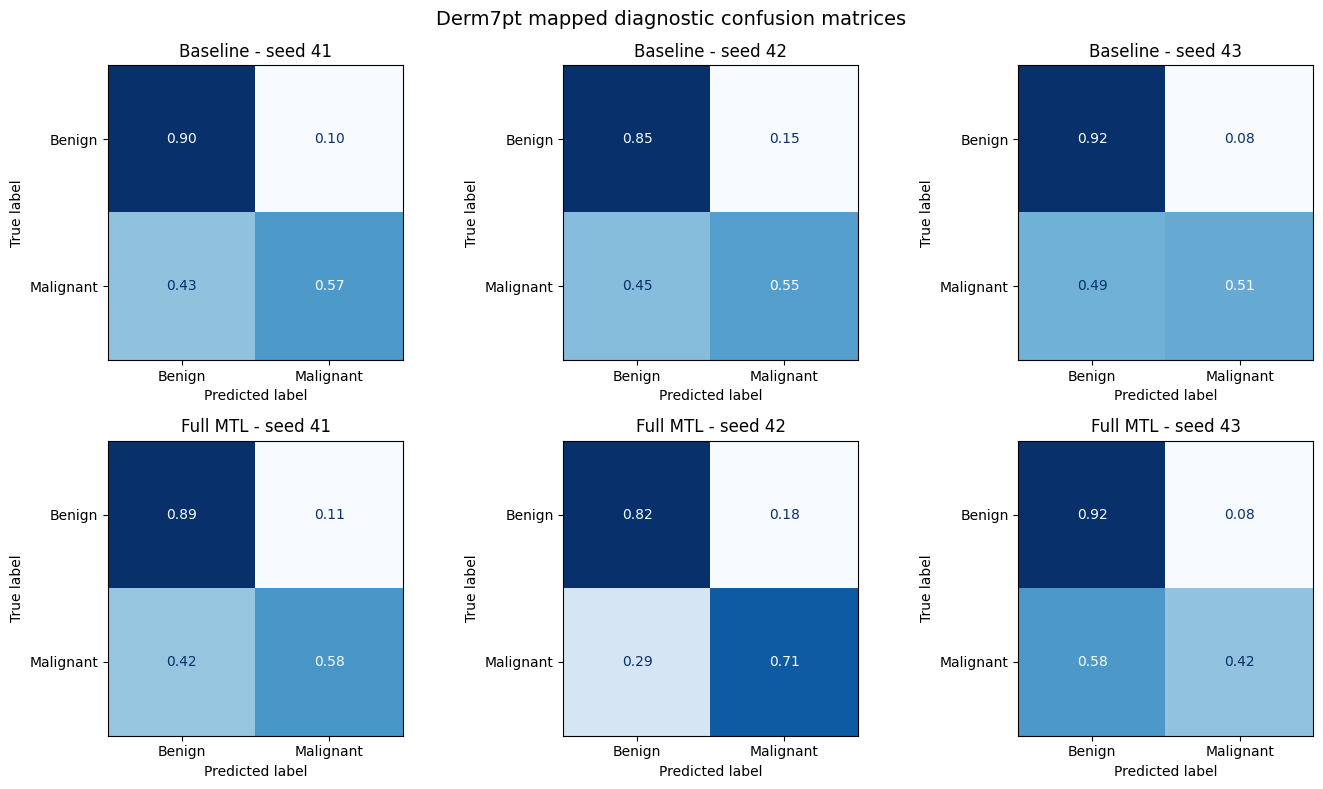

In [93]:
## Plot normalised Derm7pt confusion matrices


fig, axes = plt.subplots(2, 3, figsize=(14, 8))


for row_index, model in enumerate(MODEL_NAMES):

    for column_index, seed in enumerate(FINAL_TRAIN_SEEDS):

        dataframe = derm7pt_confusion[
            (derm7pt_confusion["Model"] == model)
            & (derm7pt_confusion["Seed"] == seed)
        ]

        confusion = confusion_matrix(
            dataframe["binary_label"].astype(int),
            dataframe["Predicted malignant"].astype(int),
            labels=[0, 1],
            normalize="true",
        )

        display_matrix = ConfusionMatrixDisplay(
            confusion_matrix=confusion,
            display_labels=["Benign", "Malignant"],
        )

        display_matrix.plot(
            ax=axes[row_index, column_index],
            cmap="Blues",
            colorbar=False,
            values_format=".2f",
        )

        axes[row_index, column_index].set_title(
            f"{model} - seed {seed}"
        )


fig.suptitle(
    "Derm7pt mapped diagnostic confusion matrices",
    fontsize=14
)

plt.tight_layout()

DERM7PT_CONFUSION_FIGURE_PATH = (
    DETAILED_FIGURE_DIR / "derm7pt_confusion_argmax.png"
)

plt.savefig(
    DERM7PT_CONFUSION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 15.10 Save detailed confusion outputs

Per-seed confusion counts and across-seed summaries are saved under `Detailed_Outputs/tables`.

The argmax confusion-matrix figures are saved under `Detailed_Outputs/figures`.

The original Notebook 05 outputs remain unchanged.



In [94]:
## Save detailed confusion outputs


ph2_confusion_summary = (
    ph2_confusion_by_seed
    .groupby(["Model", "Decision rule"])
    .agg(
        Sensitivity_mean=("Sensitivity", "mean"),
        Sensitivity_sd=("Sensitivity", "std"),
        Specificity_mean=("Specificity", "mean"),
        Specificity_sd=("Specificity", "std"),
        FPR_mean=("FPR", "mean"),
        FPR_sd=("FPR", "std"),
    )
    .reset_index()
)


derm7pt_confusion_summary = (
    derm7pt_confusion_by_seed
    .groupby(["Model", "Decision rule"])
    .agg(
        Sensitivity_mean=("Sensitivity", "mean"),
        Sensitivity_sd=("Sensitivity", "std"),
        Specificity_mean=("Specificity", "mean"),
        Specificity_sd=("Specificity", "std"),
        FPR_mean=("FPR", "mean"),
        FPR_sd=("FPR", "std"),
    )
    .reset_index()
)


ph2_confusion_by_seed.to_csv(
    DETAILED_TABLE_DIR / "ph2_confusion_by_seed.csv",
    index=False
)

ph2_confusion_summary.to_csv(
    DETAILED_TABLE_DIR / "ph2_confusion_summary.csv",
    index=False
)

derm7pt_confusion_by_seed.to_csv(
    DETAILED_TABLE_DIR / "derm7pt_confusion_by_seed.csv",
    index=False
)

derm7pt_confusion_summary.to_csv(
    DETAILED_TABLE_DIR / "derm7pt_confusion_summary.csv",
    index=False
)


print("=" * 67)
print(f"{'Detailed confusion outputs saved':^67}")
print("=" * 67, "\n")

print(f"Tables  : {DETAILED_TABLE_DIR}")
print(f"Figures : {DETAILED_FIGURE_DIR}")

                 Detailed confusion outputs saved                  

Tables  : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder/Detailed_Outputs/tables
Figures : /content/drive/MyDrive/Dissertation_Data/FinalEvaluation_Folder/Detailed_Outputs/figures
